# Volume of a Solid of Revolution via Gauss's Theorem

We consider a **solid of revolution** (“barrel shape”) obtained by rotating
a meridional curve ρ(z) around the z-axis:

- z ∈ [−h, h] is the axial coordinate
- ρ(z) is the radial coordinate
- The cross-section in the (ρ, z) plane is an ellipse:

$
\rho(z) = a\,\sqrt{1 - \frac{z^2}{b^2}}
$

Rotating this ellipse about the z-axis gives an axisymmetric body.

Using the **Gauss divergence theorem**, one can derive an analytical
expression for the volume:

$
V = 2\pi a^2 h \left(1 - \frac{h^2}{3 b^2}\right).
$

Below, we:

1. Define the geometric parameters \(h, a, b\).
2. Sample the meridional profile ρ(z).
3. Compute the volume from the analytic formula.
4. Visualize the 3D surface generated by rotation around the z-axis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

# Geometric parameters
h = 2.0       # half-height of the body along z [arbitrary units]
a = 1.5       # equatorial radius scaling in the ρ-direction

# The parameter b controls the z-extent of the ellipse in the meridional plane.
b = h / np.sqrt(1.0 - 1.0 / a**2)

print(f"h = {h:.3f}, a = {a:.3f}, b = {b:.3f}")



h = 2.000, a = 1.500, b = 2.683


## 2. Meridional profile ρ(z)

We define a 1D grid in z and compute the radius ρ(z) of the ellipse:

$
z \in [-h, h], \quad
\rho(z) = a \sqrt{1 - \frac{z^2}{b^2}}.
$

Only points with $|z| \le b$ give real values; for our choice of parameters,
the range $[-h, h]$ is within the ellipse extent.

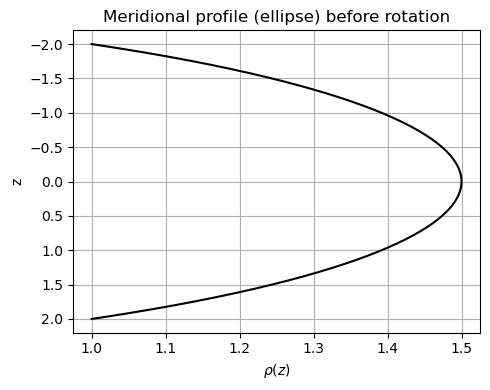

In [2]:
# Axial coordinate z
z = np.linspace(-h, h, 201)

# Radial coordinate ρ(z) for the ellipse
rho = a * np.sqrt(1.0 - (z**2) / b**2)

# (Optional) 2D plot of meridional profile (ρ vs z)
plt.figure(figsize=(5, 4))
plt.plot(rho, z, "k-")
plt.gca().invert_yaxis()  # optional: flip axis for visual comparison to Matlab
plt.xlabel(r"$\rho(z)$")
plt.ylabel("z")
plt.title("Meridional profile (ellipse) before rotation")
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. Volume via Gauss’s theorem

The volume of the axisymmetric solid of revolution generated by rotating
ρ(z) around the z-axis, for z ∈ [−h, h], can be derived using the
**Gauss divergence theorem**. The result used in the original Matlab code is:

$
V = 2\pi a^2 h \left(1 - \frac{h^2}{3 b^2}\right).
$

We compute that scalar value here.

Volume of the rotational body (Gauss theorem formula): V = 23.0383 [units³]


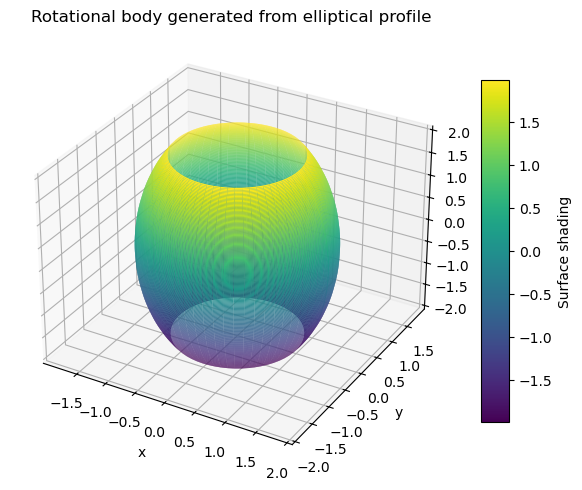

In [3]:
V = 2.0 * np.pi * a**2 * h * (1.0 - (h**2) / (3.0 * b**2))
print(f"Volume of the rotational body (Gauss theorem formula): V = {V:.4f} [units³]")

# Angular coordinate φ for revolution
phi = np.arange(0.0, 2.0 * np.pi + 0.1, 0.1)

# 2D grids for z and φ
Z, PHI = np.meshgrid(z, phi, indexing="xy")

# Broadcast ρ(z) along φ dimension to match shape of Z and PHI
rho_2d = np.tile(rho, (phi.size, 1))

# Convert cylindrical coordinates (ρ, φ, z) → Cartesian (x, y, z)
X = rho_2d * np.cos(PHI)
Y = rho_2d * np.sin(PHI)

# 3D surface plot
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X, Y, Z,
    rstride=1, cstride=1,
    cmap="viridis",
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Rotational body generated from elliptical profile")

# Equal aspect ratio for x, y, z (approx)
max_range = np.array([
    X.max() - X.min(),
    Y.max() - Y.min(),
    Z.max() - Z.min()
]).max() / 2.0
mid_x = (X.max() + X.min()) / 2.0
mid_y = (Y.max() + Y.min()) / 2.0
mid_z = (Z.max() + Z.min()) / 2.0
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

fig.colorbar(surf, shrink=0.6, aspect=12, label="Surface shading")
plt.tight_layout()
plt.show()
